In [1]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


**ACCESS DATASET**

In [2]:
import pandas as pd
df=pd.read_csv("student-mat.csv",sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.shape

(395, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**CHECKING NULL VALUES**

In [6]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


**FEATURE ENGINEERING**

Convert G3 to 0 (NOT AT RISK) / 1 (AT RISK)

In [7]:
df['dropout'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)

df[['G3', 'dropout']].head()

,G3,dropout
0,6,1
1,6,1
2,10,0
3,15,0
4,10,0


In [8]:
df['dropout'].value_counts()

,count
dropout,
0,265
1,130


**67%** of data consists "Not At Risk" Samples

**33%** of data consists "At Risk" Samples

In [9]:
df['dropout'].value_counts(normalize=True)

,proportion
dropout,
0,0.670886
1,0.329114


Dropping G3 Column for preventing Data Leakage

In [10]:
df = df.drop('G3', axis=1)

In [11]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'dropout'],
      dtype='object')

Differentiating **X,y**

In [12]:
X = df.drop('dropout', axis=1)
y = df['dropout']

X.shape, y.shape

((395, 32), (395,))

In [13]:
X.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


Converting Categorical values to Numbers **Using ONE HOT ENCODING**

In [14]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(395, 41)

Dropping G2 Feature to make model Early Intervention

In [15]:
X_no_g2 = X.drop('G2', axis=1)
X_no_g2.shape

(395, 40)

Splitting the Data into **Train & Test**

In [16]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_g2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Normalization of values

In [17]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

Training & Testing **Logistic Regression** Model & Evaluating

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_auc_score, classification_report,confusion_matrix

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2_scaled, y_train2)

y_prob2 = model2.predict_proba(X_test2_scaled)[:,1]
y_pred2 = model2.predict(X_test2_scaled)


print("Accuracy:", accuracy_score(y_test2, y_pred2))
print("Logistic (No G2) ROC-AUC:", roc_auc_score(y_test2, y_prob2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred2))
print("\nClassification Report:\n", classification_report(y_test2, y_pred2))

Accuracy: 0.8354430379746836
Logistic (No G2) ROC-AUC: 0.9274310595065313

Confusion Matrix:
 [[47  6]
 [ 7 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88        53
           1       0.76      0.73      0.75        26

    accuracy                           0.84        79
   macro avg       0.82      0.81      0.81        79
weighted avg       0.83      0.84      0.83        79



Training & Testing **Random Forest** Model & Evaluating

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)

y_prob_rf2 = rf2.predict_proba(X_test2)[:,1]
y_pred_rf2 = rf2.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, y_pred_rf2))
print("Random Forest (No G2) ROC-AUC:", roc_auc_score(y_test2, y_prob_rf2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred_rf2))
print("\nClassification Report:\n", classification_report(y_test2, y_pred_rf2))

Accuracy: 0.810126582278481
Random Forest (No G2) ROC-AUC: 0.9136429608127721

Confusion Matrix:
 [[47  6]
 [ 9 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        53
           1       0.74      0.65      0.69        26

    accuracy                           0.81        79
   macro avg       0.79      0.77      0.78        79
weighted avg       0.81      0.81      0.81        79



Training & Testing **Gradient Boosting Classifier** Model & Evaluating

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train2, y_train2)

y_prob_gb = gb.predict_proba(X_test2)[:,1]
y_pred_gb = gb.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test2, y_prob_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test2, y_pred_gb))

Accuracy: 0.810126582278481
Gradient Boosting ROC-AUC: 0.9238026124818578

Confusion Matrix:
 [[46  7]
 [ 8 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86        53
           1       0.72      0.69      0.71        26

    accuracy                           0.81        79
   macro avg       0.79      0.78      0.78        79
weighted avg       0.81      0.81      0.81        79



Finding which features were dependent for classification

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X_no_g2.columns,
    'Coefficient': model2.coef_[0]
})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

Most Dependent for **AT RISK**

In [22]:
feature_importance.head(5)

,Feature,Coefficient
0,age,0.546341
39,romantic_yes,0.425930
23,Fjob_health,0.401719
25,Fjob_services,0.390645
12,absences,0.355153


Most Dependent for **NOT AT RISK**

In [23]:
feature_importance.tail(5)

,Feature,Coefficient
28,reason_other,-0.352212
27,reason_home,-0.410600
6,famrel,-0.429931
10,Walc,-0.585838
13,G1,-3.637951


Finding Risk Scores

In [24]:
risk_scores = model2.predict_proba(X_test2_scaled)[:,1]

Comparing risk scores with actual

In [25]:
risk_df = pd.DataFrame({
    'Risk_Score': risk_scores,
    'Actual_Label': y_test2.values
})

risk_df.head(10)

,Risk_Score,Actual_Label
0,0.953577,1
1,0.399574,0
2,0.810234,0
3,0.269126,1
4,0.597007,1
5,0.019458,0
6,0.007446,0
7,0.000145,0
8,0.470401,1
9,0.007464,0


Classifying Into Risk Levels

HIGH RISK , MEDIUM RISK , LOW RISK

In [26]:
def risk_category(score):
    if score >= 0.7:
        return "High Risk"
    elif score >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df['Risk_Level'] = risk_df['Risk_Score'].apply(risk_category)
risk_df.head(20)

,Risk_Score,Actual_Label,Risk_Level
0,0.953577,1,High Risk
1,0.399574,0,Low Risk
2,0.810234,0,High Risk
3,0.269126,1,Low Risk
4,0.597007,1,Medium Risk
5,0.019458,0,Low Risk
6,0.007446,0,Low Risk
7,0.000145,0,Low Risk
8,0.470401,1,Medium Risk
9,0.007464,0,Low Risk


Comparision of Metrics of the 3 Model's by Plotting bar graph

Model Performance Summary:
                         Model  Accuracy   ROC-AUC    Recall
0  Logistic Regression (No G2)  0.835443  0.927431  0.730769
1        Random Forest (No G2)  0.810127  0.913643  0.653846
2            Gradient Boosting  0.810127  0.923803  0.692308


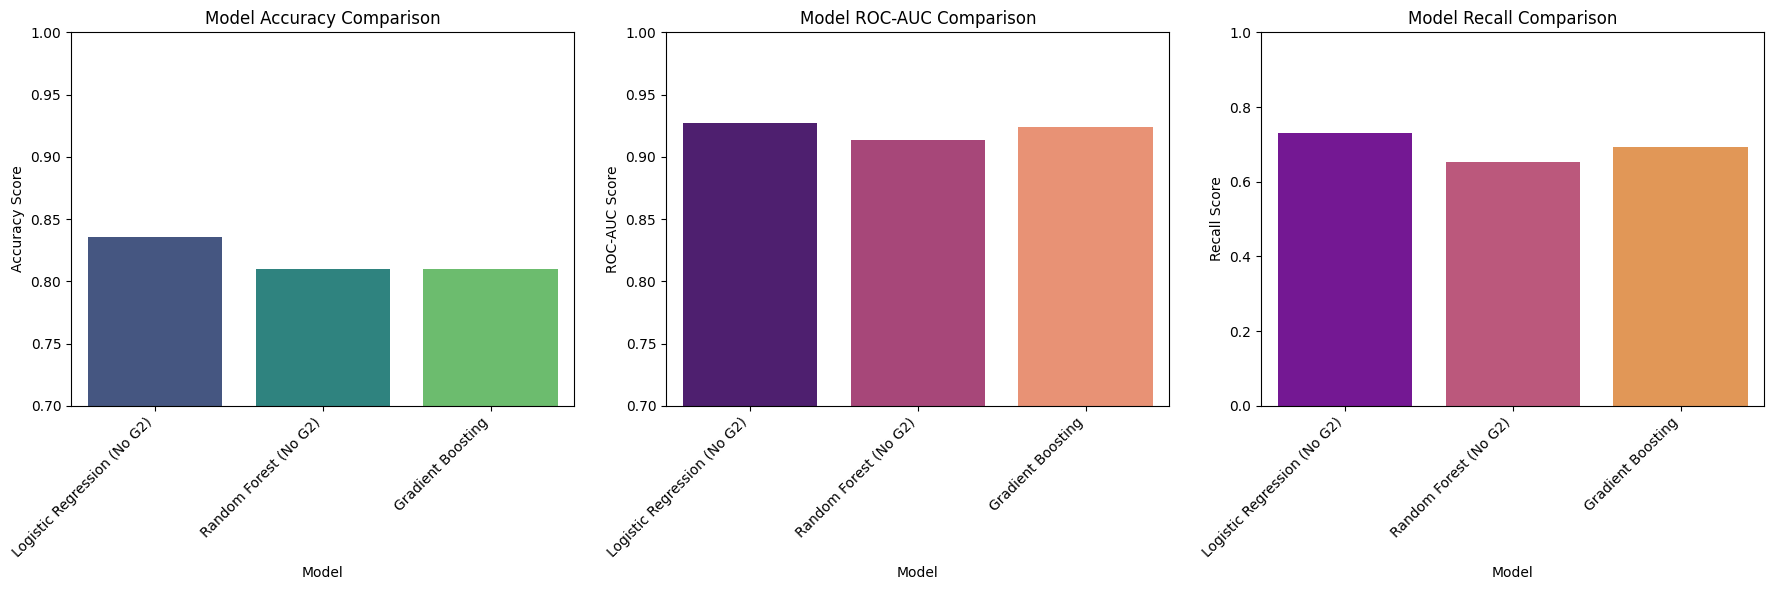

In [27]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate recall scores
recall_lr = recall_score(y_test2, y_pred2, pos_label=1)
recall_rf = recall_score(y_test2, y_pred_rf2, pos_label=1)
recall_gb = recall_score(y_test2, y_pred_gb, pos_label=1)

# Re-calculate or retrieve accuracy and ROC-AUC for all models for consistency
accuracy_lr = accuracy_score(y_test2, y_pred2)
roc_auc_lr = roc_auc_score(y_test2, y_prob2)

accuracy_rf = accuracy_score(y_test2, y_pred_rf2)
roc_auc_rf = roc_auc_score(y_test2, y_prob_rf2)

accuracy_gb = accuracy_score(y_test2, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test2, y_prob_gb)

# Create a DataFrame to store performance metrics
performance_df = pd.DataFrame({
    'Model': ['Logistic Regression (No G2)', 'Random Forest (No G2)', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_gb],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_gb],
    'Recall': [recall_lr, recall_rf, recall_gb]
})

print("Model Performance Summary:")
print(performance_df)

# Create bar plots for comparison
plt.figure(figsize=(18, 6))

# Plot for Accuracy
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.7, 1.0) # Set y-limit for better visualization
plt.xticks(rotation=45, ha='right')

# Plot for ROC-AUC
plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='ROC-AUC', data=performance_df, palette='magma', hue='Model', legend=False)
plt.title('Model ROC-AUC Comparison')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.7, 1.0) # Set y-limit for better visualization
plt.xticks(rotation=45, ha='right')

# Plot for Recall
plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='Recall', data=performance_df, palette='plasma', hue='Model', legend=False)
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall Score')
plt.ylim(0.0, 1.0) # Recall can range from 0 to 1
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Model Saving & Deployment

In [28]:
import joblib

In [29]:
joblib.dump(model2, 'logistic_regression_model.pkl')

['logistic_regression_model.pkl']

In [30]:
joblib.dump(scaler2, 'scaler.pkl')

['scaler.pkl']

In [31]:
joblib.dump(X_no_g2.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [32]:
from google.colab import files

files.download("logistic_regression_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Load back
loaded_model = joblib.load("logistic_regression_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_columns = joblib.load("feature_columns.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully
